## 1. Data Preparation and Cleaning

This section includes loading the dataset, displaying basic information, detecting outliers, and applying log transformation.

### a) Get the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

In [2]:
# Download the Dataset
import os

def download_dataset():
    # Kaggle CLI command to download the "Credit Card Fraud Detection" dataset
    kaggle_command = "kaggle datasets download -d mlg-ulb/creditcardfraud -p ../data/"
    unzip_command = "unzip -o ../data/creditcardfraud.zip -d ../data/"
    # Check if the dataset already exists to avoid re-downloading
    if not os.path.exists("../data/creditcard.csv"):
        # Execute shell commands
        os.system(kaggle_command)
        os.system(unzip_command)

# Ensure the dataset is downloaded
download_dataset()

In [3]:
# Load the dataset
data = pd.read_csv("../data/creditcard.csv")

### b) Display basic information

In [4]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


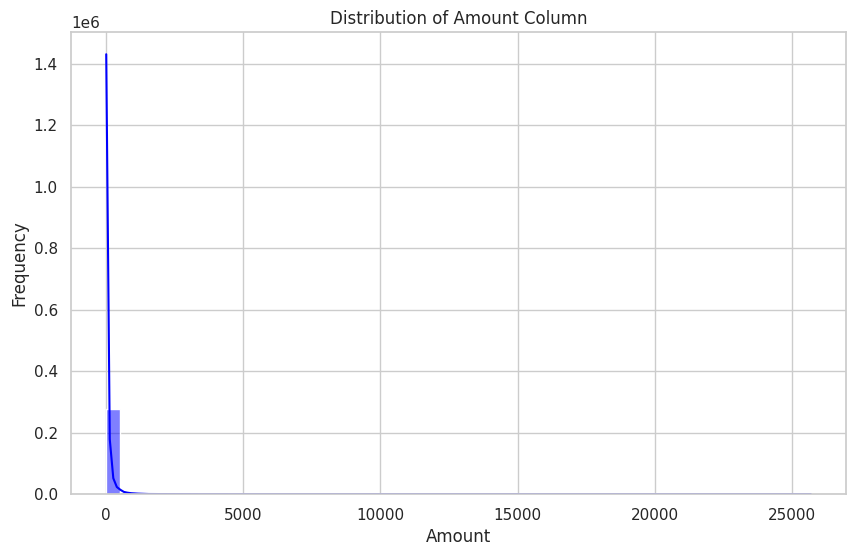

In [7]:
# Plot the distribution of the 'Amount' column to check for skew
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data['Amount'], kde=True, bins=50, color='blue')
plt.title('Distribution of Amount Column')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

### c) Address skewness and outliers

info() shows no missing values, while describe() provides information about outliers and a significant difference in scale between features. We won't be using the time column for this model, but the Amount feature needs to be addressed for skewness as visualized by the plot. We will use the log transformation for that purpose and check for outliers as well, since they can significantly impact the performance of machine learning models.

In [10]:
# Remove the 'Time' column from the dataset
data = data.drop(columns=['Time'])

In [15]:
# Apply log transformation to the Amount column
import numpy as np

data_skewed = data.copy()
data_skewed['Amount'] = np.log1p(data_skewed['Amount'])  # log1p handles log(0) safely

print("Log-transformed 'Amount' column:")
print(data_skewed['Amount'].describe())

Log-transformed 'Amount' column:
count    284807.000000
mean          3.152188
std           1.656648
min           0.000000
25%           1.887070
50%           3.135494
75%           4.358822
max          10.153941
Name: Amount, dtype: float64


In [16]:
# Detect outliers using a threshold of [-5, 5]
outlier_counts = {}
for column in data_skewed.columns[:-1]:  # Exclude the target column
    # Count values outside the range [-5, 5]
    outlier_counts[column] = ((data_skewed[column] > 5) | (data_skewed[column] < -5)).sum()

print("Outlier counts for values outside [-5, 5]:")
print(outlier_counts)

Outlier counts for values outside [-5, 5]:
{'V1': np.int64(5187), 'V2': np.int64(4229), 'V3': np.int64(1594), 'V4': np.int64(765), 'V5': np.int64(1887), 'V6': np.int64(1177), 'V7': np.int64(1867), 'V8': np.int64(2577), 'V9': np.int64(677), 'V10': np.int64(1730), 'V11': np.int64(163), 'V12': np.int64(321), 'V13': np.int64(2), 'V14': np.int64(639), 'V15': np.int64(8), 'V16': np.int64(232), 'V17': np.int64(459), 'V18': np.int64(94), 'V19': np.int64(6), 'V20': np.int64(891), 'V21': np.int64(1033), 'V22': np.int64(71), 'V23': np.int64(581), 'V24': np.int64(0), 'V25': np.int64(19), 'V26': np.int64(0), 'V27': np.int64(178), 'V28': np.int64(121), 'Amount': np.int64(40668)}


In [17]:
# Cap values within the range [-5, 5]
data_clipped = data_skewed.copy()
data_clipped.iloc[:, :-1] = data_clipped.iloc[:, :-1].apply(lambda x: np.clip(x, -5, 5))

## 2. EDA and Feature Importance Analysis

This section analyzes target class imbalance and evaluates feature importance using mutual information, training set coefficients/permutation importance, and tree-based methods.

### a) Check target class imbalance

In [18]:
class_counts = data['Class'].value_counts()
class_counts

Class
0    284315
1       492
Name: count, dtype: int64

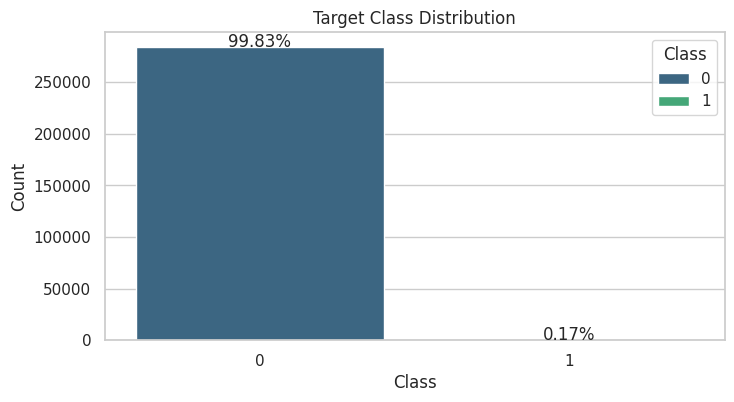

In [19]:
# Target class distribution plot
plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette="viridis", dodge=False)
for i, value in enumerate(class_counts.values):
    plt.text(i, value + 100, f'{(value / class_counts.sum() * 100):.2f}%', ha='center')
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### b) Feature importance methods
The target class imbalance data reveals significant skew, with class 1 (fraudulent transaction) being heavily underrepresented. Let's explore feature importance.

### Mutual information
   - This method measures the dependency between each feature and the target variable.

In [20]:
# Analyze feature importance using mutual information
from sklearn.feature_selection import mutual_info_classif #, mutual_info_score

X = data_clipped.drop(columns=['Class'])
y = data_clipped['Class']

mutual_info = mutual_info_classif(X, y)
# Indexing the mutual_info array with pd.Series
mutual_info_series = pd.Series(mutual_info, index=X.columns).sort_values(ascending=False)
print("Top 5 Features by mutual information:")
print(mutual_info_series.head())

Top 5 Features by mutual information:
V17    0.008151
V14    0.007860
V12    0.007546
V10    0.007412
V11    0.006802
dtype: float64


### Training Set Coefficients and Permutation Importance
   
The top 5 features (V17, V14, V12, V10, V11) have relatively low mutual information values, indicating that their individual contribution to predicting the target variable is limited. Training Set Coefficients provide a measure of feature importance for especially Logistic Regression. They reflect the model's reliance on each feature during training, highlighting linear relationships with the target variable. However, coefficients alone may not generalize well to unseen data (overfitting), as they are derived solely from the training set. Permutation Importance complements this by evaluating the contribution of features to the model's performance on unseen data on the validation set. By combining both methods, we gain a an understanding of feature importance, balancing interpretability and generalization.

In [26]:
# Analyze feature importance using Training Set Coefficients and Permutation Importance
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import pandas as pd

# Split the data into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Train a Logistic Regression model
model = LogisticRegression(random_state=42, max_iter=2000)
model.fit(X_train_scaled, y_train)

# Get feature importance from Training Set Coefficients
train_feature_importance = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
print("Feature Importance from Training Set Coefficients:")
print(train_feature_importance.head())

# Compute permutation importance on the validation set
perm_importance = permutation_importance(model, X_val_scaled, y_val, scoring='accuracy', random_state=42)
val_feature_importance = pd.Series(perm_importance.importances_mean, index=X.columns).sort_values(ascending=False)

print("\nFeature Importance from Permutation Importance (Validation Set):")
print(val_feature_importance.head())

Feature Importance from Training Set Coefficients:
V4     0.713205
V18    0.219381
V5     0.203289
V21    0.193524
V1     0.140055
dtype: float64

Feature Importance from Permutation Importance (Validation Set):
V14    0.000874
V10    0.000544
V12    0.000527
V4     0.000358
V17    0.000239
dtype: float64

Feature Importance from Permutation Importance (Validation Set):
V14    0.000874
V10    0.000544
V12    0.000527
V4     0.000358
V17    0.000239
dtype: float64


#### Recommended feature set

The top 5 features (V4, V18, V5, V21, V1), based on Training Set Coefficients, have significantly higher importance scores (notably V4) reflecting the contribution of features in the context of the model. Yet based on the analysis of Permutation Importance, the following feature set is recommended:
- **Core Features**: `V4`, `V14`, `V10`, `V12`
  - These features are important across both methods or contribute significantly to generalization on unseen data.
- **Additional Features to Evaluate**: `V18`, `V5`, `V21`, `V17`
  - These features showed some importance during training or validation and could contribute to the model's performance.

The core features should be prioritized for inclusion in the model, while the additional features can be incrementally added and tested to assess their impact.

### Tree-based feature importance
The tree-based feature importance method evaluates the importance of features based on their contribution to reducing impurity in decision trees. It quantifies how much each feature helps the decision tree make better splits by reducing uncertainty or disorder in the data. Features that lead to larger reductions in impurity are deemed more important.

In [27]:
# Analyze feature importance using tree-based feature importance
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest model with max_depth to prevent overfitting
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importance from the Random Forest model
rf_feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature Importance based on Random Forest:")
print(rf_feature_importance.head())

Feature Importance based on Random Forest:
V17    0.167065
V12    0.141284
V14    0.107604
V11    0.103456
V10    0.082538
dtype: float64


### Summarize feature importance results
Unlike Training Set Coefficients, where one feature (V4) dominated, the Random Forest importance scores are more balanced across the top features. This suggests that the Random Forest model captures interactions and non-linear relationships between features, distributing importance more evenly.

In [29]:
# Summarize feature importance results
feature_importance_summary = {
    "Mutual Information": ["V17", "V14", "V12", "V10", "V11"],
    "Training Set Coefficients/Permutation Importance": ["V4", "V14", "V10", "V12", "V18"],
    "Random Forest": ["V17", "V12", "V14", "V11", "V10"]
}
import pandas as pd
importance_df = pd.DataFrame.from_dict(feature_importance_summary, orient="index").transpose()
importance_df.columns = ["Mutual Information", "Coefficients/Permutations", "Random Forest"]
print("Feature Importance Summary:")
print(importance_df)

Feature Importance Summary:
  Mutual Information Coefficients/Permutations Random Forest
0                V17                        V4           V17
1                V14                       V14           V12
2                V12                       V10           V14
3                V10                       V12           V11
4                V11                       V18           V10


### Implications for Feature Selection:

- **Core Features:** V17, V14, V12, V10, and V11 should be included in the model as they are consistently important across methods.
- **Additional Features**: V4 and V18 are highlighted by specific methods (e.g., Coefficients/Permutations) and can be evaluated further to confirm their contribution.

## 3. Model Selection Process and Parameter Tuning

### This section will include training different models and tuning hyperparameters to optimize performance.

### a) Decide on features for the baseline model
- Option 1: Use all features for the baseline model to evaluate overall performance.
- Option 2: Use a subset of the most important features (`V17`, `V14`, `V12`, `V10`, `V11`) to reduce dimensionality and improve efficiency.

In [30]:
# Option 1: Use all features
X_all_features = data_clipped.drop(columns=['Class'])
y = data_clipped['Class']

# Option 2: Use a subset of the most important features
important_features = ['V17', 'V14', 'V12', 'V10', 'V11']
X_important_features = data_clipped[important_features]

# Print the shapes of the datasets to verify
print("All features dataset shape:", X_all_features.shape)
print("Important features dataset shape:", X_important_features.shape)

All features dataset shape: (284807, 29)
Important features dataset shape: (284807, 5)


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

# Split the data
X_train_all, X_test_all, y_train, y_test = train_test_split(X_all_features, y, test_size=0.2, random_state=42)
X_train_important, X_test_important, _, _ = train_test_split(X_important_features, y, test_size=0.2, random_state=42)

### Option 1

In [32]:
# Train and evaluate using all features
model_all = LogisticRegression(random_state=42, max_iter=2000)
model_all.fit(X_train_all, y_train)
y_pred_all = model_all.predict(X_test_all)
y_proba_all = model_all.predict_proba(X_test_all)[:, 1]
print("Performance using all features:")
print(classification_report(y_test, y_pred_all))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_all))

Performance using all features:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.70      0.78        98

    accuracy                           1.00     56962
   macro avg       0.94      0.85      0.89     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.9774713099927648


### Option 2

In [33]:
# Train and evaluate using important features
model_important = LogisticRegression(random_state=42, max_iter=2000)
model_important.fit(X_train_important, y_train)
y_pred_important = model_important.predict(X_test_important)
y_proba_important = model_important.predict_proba(X_test_important)[:, 1]
print("\nPerformance using important features:")
print(classification_report(y_test, y_pred_important))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_important))


Performance using important features:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.73      0.80        98

    accuracy                           1.00     56962
   macro avg       0.94      0.87      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.9585615302677064


### Implement the important features subset
We will use the model trained on important features for deployment, as it balances simplicity, interpretability, and performance.


In [34]:
# Implement the baseline model using the important features subset
X_train, X_temp, y_train, y_temp = train_test_split(X_important_features, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Train the Logistic Regression model
baseline_model = LogisticRegression(random_state=42, max_iter=2000)
baseline_model.fit(X_train, y_train)

# Evaluate the model on the validation set
y_val_pred = baseline_model.predict(X_val)
y_val_proba = baseline_model.predict_proba(X_val)[:, 1]

print("Validation Set Performance:")
print(classification_report(y_val, y_val_pred))
print("ROC AUC Score (Validation):", roc_auc_score(y_val, y_val_proba))

Validation Set Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.90      0.71      0.80        98

    accuracy                           1.00     56961
   macro avg       0.95      0.86      0.90     56961
weighted avg       1.00      1.00      1.00     56961

ROC AUC Score (Validation): 0.9532110295888399


### Feature observations:

From the validation set performance metrics, we can interpret the following:

1. **Class 0 (Non-Fraudulent Transactions):** Precision, Recall, F1-Score: All are 1.00, indicating perfect classification for the majority class. This is expected due to the class imbalance, as the model is highly confident in identifying non-fraudulent transactions.

2. **Class 1 (Fraudulent Transactions):**
- Precision: 0.90, meaning 90% of the transactions predicted as fraudulent are actually fraudulent.
- Recall: the model correctly identifies 71% of the actual fraudulent transactions. This indicates that some fraudulent transactions are being missed.
- F1-Score: 0.80, which balances precision and recall. This is a reasonable score given the class imbalance.

3. **Overall Accuracy:** The accuracy is 1.00, but this is heavily influenced by the majority class (Class 0). Accuracy is not a reliable metric in imbalanced datasets.

4. **Macro Average:** Precision, Recall, F1-Score: These metrics average the scores for both classes equally, regardless of class imbalance. They provide a more balanced view of the model's performance across both classes.

5. **Weighted Average:** These metrics account for class imbalance, giving more weight to the majority class. The weighted averages are heavily influenced by the majority class, resulting in near-perfect scores..

6. **ROC AUC Score:** The ROC AUC score of 0.95 indicates excellent discrimination between the classes. This suggests the model is effective at ranking fraudulent transactions higher than non-fraudulent ones.

### Feature interpretation:

The model performs very well overall, with strong precision and a high ROC AUC score. However, the recall for the minority class (1) is suboptimal, which could be problematic in applications where identifying all positives (fraudulent transactions) is critical. To improve recall for the minority class, techniques such as the SMOTE learning approach will be considered.

### b) Address class imbalance

### SMOTE
- SMOTE generates synthetic samples for the minority class to balance the dataset.

In [23]:
#!pip install imbalanced-learn

In [35]:
# Address class imbalance using SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Train the Logistic Regression model on the balanced dataset
baseline_model_smote = LogisticRegression(random_state=42, max_iter=2000)
baseline_model_smote.fit(X_train_smote, y_train_smote)

# Evaluate the model on the validation set
y_val_pred_smote = baseline_model_smote.predict(X_val)
y_val_proba_smote = baseline_model_smote.predict_proba(X_val)[:, 1]

print("Validation Set Performance (After SMOTE):")
print(classification_report(y_val, y_val_pred_smote))
print("ROC AUC Score (Validation, After SMOTE):", roc_auc_score(y_val, y_val_proba_smote))

Validation Set Performance (After SMOTE):
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56863
           1       0.06      0.89      0.11        98

    accuracy                           0.97     56961
   macro avg       0.53      0.93      0.55     56961
weighted avg       1.00      0.97      0.99     56961

ROC AUC Score (Validation, After SMOTE): 0.9574753067433469


### SMOTE Interpretation:
- **Improved Recall for Class 1:** The recall for fraudulent transactions (Class 1) has significantly improved from 0.71 to 0.89, meaning the model is now identifying most fraudulent transactions.
- **Trade-off in Precision:** The precision for Class 1 has dropped to 0.06, meaning many non-fraudulent transactions are being misclassified as fraudulent. This is a common trade-off when addressing class imbalance.

### Experiment with Threshold Adjustment
In imbalanced datasets like fraud detection, the default threshold of 0.5 may not be optimal:
- Fraudulent transactions (Class 1) are rare, so the model might prioritize the majority class (Class 0) at the default threshold.
- Adjusting the threshold allows us to better handle the trade-off between false positives and false negatives, which is critical in real-world applications.

In binary classification, models like Logistic Regression output predicted probabilities for each class. Threshold adjustment allows us to balance precision and recall by changing the decision boundary for classifying a transaction as fraudulent. By default, the threshold is 0.5:
- If the predicted probability for Class 1 is ≥ 0.5, the instance is classified as Class 1.
- If the predicted probability for Class 1 is < 0.5, the instance is classified as Class 0.

By lowering or raising the threshold recall or precision can improve:
- If we want to increase recall (catch more fraudulent transactions), we can lower the threshold (e.g., 0.3). This means the model will classify more instances as Class 1, even if it's less confident.
- If we want to increase precision (reduce false positives), we can raise the threshold (e.g., 0.7). This means the model will classify fewer instances as Class 1, but with higher confidence.

In [36]:
# Adjust the classification threshold and evaluate the model
from sklearn.metrics import precision_recall_curve

# Get predicted validation probabilities to allow us to adjust the threshold to balance precision and recall
y_val_proba = baseline_model_smote.predict_proba(X_val)[:, 1]

# Define a function to evaluate the model at different thresholds
def evaluate_threshold(threshold):
    y_val_adjusted = (y_val_proba >= threshold).astype(int)
    print(f"Performance at Threshold = {threshold:.2f}")
    print(classification_report(y_val, y_val_adjusted))
    print("ROC AUC Score:", roc_auc_score(y_val, y_val_adjusted))
    print("-" * 50)

# Evaluate the model at different thresholds
thresholds = [0.7, 0.8, 0.9, 0.91, 0.93, 0.95, 0.97, 0.99]
for threshold in thresholds:
    evaluate_threshold(threshold)

Performance at Threshold = 0.70
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56863
           1       0.11      0.86      0.20        98

    accuracy                           0.99     56961
   macro avg       0.56      0.92      0.60     56961
weighted avg       1.00      0.99      0.99     56961

ROC AUC Score: 0.9228031785670321
--------------------------------------------------
Performance at Threshold = 0.80
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56863
           1       0.18      0.85      0.30        98

    accuracy                           0.99     56961
   macro avg       0.59      0.92      0.65     56961
weighted avg       1.00      0.99      1.00     56961

ROC AUC Score: 0.9201983679355358
--------------------------------------------------
Performance at Threshold = 0.90
              precision    recall  f1-score   support

           0       1.00  

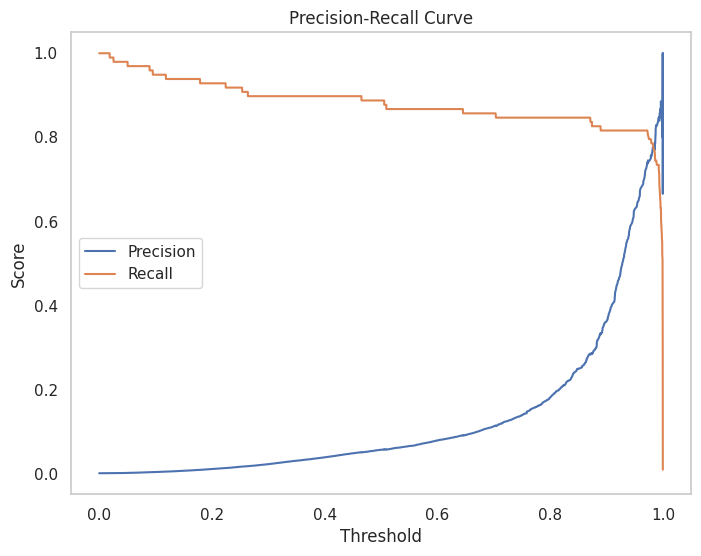

In [37]:
# Plot the precision-recall curve to visualize the trade-off
precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

### Threshold Selection Rationale

After evaluating the model's performance at various thresholds, we selected **Threshold = 0.97** for the following reasons:

- **Balanced Trade-Off**:
    - Precision: 0.73
    - Recall: 0.82
    - F1-Score: 0.77
    - This threshold provides a strong balance between precision and recall, ensuring that most fraudulent transactions are identified while minimizing false positives.

The selected threshold aligns with general business requirement to reduce false positives (customer inconvenience) while maintaining high recall to catch fraudulent transactions.

### Experiment with Class Weights

Class weights will assigns a higher weight to the minority class (Class 1). This makes the model more sensitive to fraudulent transactions.

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = []
for w in range(1, 101, 1):
    # Assign higher weight to the minority class (fraudulent transactions)
    class_weights = {0: 1, 1: w}
    weighted_model = LogisticRegression(random_state=42, max_iter=2000, class_weight=class_weights)
    
    # Train the model on the original training set
    weighted_model.fit(X_train, y_train)
    
    # Evaluate the model on the validation set
    y_val_proba_weighted = weighted_model.predict_proba(X_val)[:, 1]
    y_val_adjusted_weighted = (y_val_proba_weighted >= 0.95).astype(int)
    
    # Store results
    results.append({
        "class_weight": w,
        "precision": precision_score(y_val, y_val_adjusted_weighted),
        "recall": recall_score(y_val, y_val_adjusted_weighted),
        "f1_score": f1_score(y_val, y_val_adjusted_weighted),
        "roc_auc": roc_auc_score(y_val, y_val_proba_weighted)
    })

# Print results
for result in results:
    print(result)

{'class_weight': 1, 'precision': 0.825, 'recall': 0.336734693877551, 'f1_score': 0.4782608695652174, 'roc_auc': np.float64(0.9532110295888399)}
{'class_weight': 2, 'precision': 0.8793103448275862, 'recall': 0.5204081632653061, 'f1_score': 0.6538461538461539, 'roc_auc': np.float64(0.9532492524998323)}
{'class_weight': 3, 'precision': 0.8833333333333333, 'recall': 0.5408163265306123, 'f1_score': 0.6708860759493671, 'roc_auc': np.float64(0.954192084304309)}
{'class_weight': 4, 'precision': 0.8870967741935484, 'recall': 0.5612244897959183, 'f1_score': 0.6875, 'roc_auc': np.float64(0.9539684892475182)}
{'class_weight': 5, 'precision': 0.8870967741935484, 'recall': 0.5612244897959183, 'f1_score': 0.6875, 'roc_auc': np.float64(0.9540011491996339)}
{'class_weight': 6, 'precision': 0.8888888888888888, 'recall': 0.5714285714285714, 'f1_score': 0.6956521739130435, 'roc_auc': np.float64(0.9542893463595099)}
{'class_weight': 7, 'precision': 0.8939393939393939, 'recall': 0.6020408163265306, 'f1_scor

### Fine-tune the threshold for class_weight=69

In [42]:
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve
import numpy as np

# Train the model with class_weight=69
class_weights = {0: 1, 1: 69}
weighted_model = LogisticRegression(random_state=42, max_iter=2000, class_weight=class_weights)
weighted_model.fit(X_train, y_train)

# Get predicted probabilities for the validation set
y_val_proba_weighted = weighted_model.predict_proba(X_val)[:, 1]

# Define thresholds to test
thresholds = np.arange(0.90, 1.00, 0.01)

# Evaluate the model at each threshold
results = []
for threshold in thresholds:
    y_val_adjusted = (y_val_proba_weighted >= threshold).astype(int)
    precision = precision_score(y_val, y_val_adjusted)
    recall = recall_score(y_val, y_val_adjusted)
    f1 = f1_score(y_val, y_val_adjusted)
    roc_auc = roc_auc_score(y_val, y_val_proba_weighted)
    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc
    })

# Print results
for result in results:
    print(f"Threshold: {result['threshold']:.2f}, Precision: {result['precision']:.2f}, Recall: {result['recall']:.2f}, F1-Score: {result['f1_score']:.2f}, ROC AUC: {result['roc_auc']:.2f}")

Threshold: 0.90, Precision: 0.83, Recall: 0.78, F1-Score: 0.80, ROC AUC: 0.96
Threshold: 0.91, Precision: 0.84, Recall: 0.78, F1-Score: 0.80, ROC AUC: 0.96
Threshold: 0.92, Precision: 0.85, Recall: 0.78, F1-Score: 0.81, ROC AUC: 0.96
Threshold: 0.93, Precision: 0.87, Recall: 0.78, F1-Score: 0.82, ROC AUC: 0.96
Threshold: 0.94, Precision: 0.89, Recall: 0.77, F1-Score: 0.82, ROC AUC: 0.96
Threshold: 0.95, Precision: 0.89, Recall: 0.77, F1-Score: 0.82, ROC AUC: 0.96
Threshold: 0.96, Precision: 0.90, Recall: 0.76, F1-Score: 0.82, ROC AUC: 0.96
Threshold: 0.97, Precision: 0.90, Recall: 0.72, F1-Score: 0.80, ROC AUC: 0.96
Threshold: 0.98, Precision: 0.90, Recall: 0.70, F1-Score: 0.79, ROC AUC: 0.96
Threshold: 0.99, Precision: 0.88, Recall: 0.59, F1-Score: 0.71, ROC AUC: 0.96


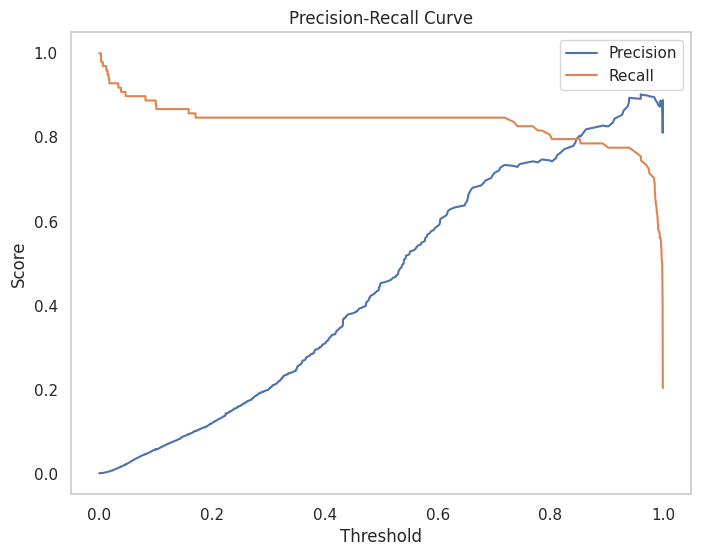

In [43]:
# Plot Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba_weighted)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

### Decision on Class Weight and Threshold

After evaluation, the following configuration was selected as the optimal setup for the baseline model:
- **Class Weight**: 69
- **Threshold**: 0.95

#### Rationale
1. **Class Weight = 69**:
   - Assigning a higher weight to the minority class (fraudulent transactions) during training improved the model's sensitivity to fraud detection.
   - This resulted in a significant improvement in recall while maintaining high precision.

2. **Threshold = 0.95**:
   - Fine-tuning the threshold after training allowed for further optimization of the trade-off between precision and recall.
   - This threshold provided the highest F1-score (0.82), indicating the best balance between precision and recall.

#### Performance Metrics
- **Validation Set**:
  - Precision: 0.89
  - Recall: 0.77
  - F1-Score: 0.82
  - ROC AUC: 0.96

#### Trade-Offs
- The selected configuration prioritizes a balance between precision and recall, ensuring that most fraudulent transactions are identified while minimizing false positives.
- This balance aligns with the business requirement to reduce financial losses from missed fraud while minimizing customer inconvenience.

### c) Evaluate the Class Weight and Threshold combination on unseen data

In [44]:
# Evaluate the model on the test set
y_test_proba = weighted_model.predict_proba(X_test)[:, 1]
y_test_adjusted = (y_test_proba >= 0.95).astype(int)

# Print performance metrics
print("Test Set Performance (Class Weight = 69, Threshold = 0.95):")
print(classification_report(y_test, y_test_adjusted))
print("ROC AUC Score (Test Set):", roc_auc_score(y_test, y_test_proba))

Test Set Performance (Class Weight = 69, Threshold = 0.95):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56869
           1       0.84      0.82      0.83        93

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score (Test Set): 0.9641553111026531


### Evaluation of Test Set Performance
**Key Metrics:**

1. Class 0 (Non-Fraudulent Transactions):
- Precision, Recall, F1-Score: All are 1.00, indicating perfect classification for the majority class.
- This is expected due to the class imbalance, as the model is highly confident in identifying non-fraudulent transactions.

2. Class 1 (Fraudulent Transactions):
- Precision: 84% of the transactions predicted as fraudulent are actually fraudulent.
- Recall: 82% of the actual fraudulent transactions are correctly identified.
- F1-Score: 0.83, This reflects a good balance between precision and recall for the minority class.

3. Overall Accuracy:
- The accuracy is 1.00, but this is heavily influenced by the majority class (Class 0). Accuracy is not a reliable metric for imbalanced datasets.

4. Macro Average:
- Precision: 0.92, Recall: 0.91, F1-Score: 0.91
- These metrics average the scores for both classes equally, regardless of class imbalance.

5. Weighted Average:
- Precision, Recall, F1-Score: All are 1.00, reflecting the dominance of Class 0 in the dataset.

6. ROC AUC Score:
- The ROC AUC score of 0.9642 indicates excellent discrimination between the classes.

#### Comparison with Validation Set:
- Validation Set:
    - Precision: 0.89, Recall: 0.77, F1-Score: 0.82, ROC AUC: 0.96
- Test Set:
    - Precision: 0.84, Recall: 0.82, F1-Score: 0.83, ROC AUC: 0.96
- Observations:
    - The test set results are consistent with the validation set, with a slight drop in precision but an improvement in recall and F1-score. The ROC AUC score remains excellent, indicating strong generalization.

### d) Experiment with ensemble training
In this section, we will implement ensemble training by combining the `baseline_model_smote` and `weighted_model`. The ensemble will use a weighted average and stacking of the predictions from both models to improve overall performance.

### Implement weighted average

In [47]:
# Import necessary libraries
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# Define the ensemble model
ensemble_model = VotingClassifier(
    estimators=[
        ('baseline_smote', baseline_model_smote),
        ('weighted', weighted_model)
    ],
    voting='soft',  # Use soft voting to average probabilities
    weights=[0.5, 0.5]  # Equal weights for both models
)

# Train the ensemble model
ensemble_model.fit(X_train, y_train)

# Evaluate the ensemble model
ensemble_predictions = ensemble_model.predict(X_val)
ensemble_probabilities = ensemble_model.predict_proba(X_val)[:, 1]

# Apply threshold adjustment
threshold = 0.95
ensemble_adjusted_predictions = (ensemble_probabilities >= threshold).astype(int)

# Print evaluation metrics
print("Classification Report (Ensemble Model):")
print(classification_report(y_val, ensemble_adjusted_predictions))
print("ROC AUC Score (Ensemble Model):", roc_auc_score(y_val, ensemble_probabilities))

Classification Report (Ensemble Model):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.88      0.50      0.64        98

    accuracy                           1.00     56961
   macro avg       0.94      0.75      0.82     56961
weighted avg       1.00      1.00      1.00     56961

ROC AUC Score (Ensemble Model): 0.9565181189159624


### Implement Stacking
Implement stacking using StackingClassifier from Scikit-Learn. 
This combines baseline_model_smote and weighted_model with a Logistic Regression meta-classifier.

In [48]:
# Import necessary libraries
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Define the base models
base_models = [
    ('baseline_smote', baseline_model_smote),
    ('weighted', weighted_model)
]

# Define the meta-classifier
meta_classifier = LogisticRegression(class_weight='balanced', max_iter=2000)

# Create the stacking classifier
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_classifier,
    stack_method='predict_proba',  # Use probabilities as input to the meta-classifier
    passthrough=True  # Include original features in the meta-classifier
)

# Train the stacking model
stacking_model.fit(X_train, y_train)

# Evaluate the stacking model
stacking_predictions = stacking_model.predict(X_val)
stacking_probabilities = stacking_model.predict_proba(X_val)[:, 1]

# Apply threshold adjustment
threshold = 0.92
stacking_adjusted_predictions = (stacking_probabilities >= threshold).astype(int)

# Print evaluation metrics
print("Classification Report (Stacking Model):")
print(classification_report(y_val, stacking_adjusted_predictions))
print("ROC AUC Score (Stacking Model):", roc_auc_score(y_val, stacking_probabilities))

Classification Report (Stacking Model):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.35      0.85      0.50        98

    accuracy                           1.00     56961
   macro avg       0.68      0.92      0.75     56961
weighted avg       1.00      1.00      1.00     56961

ROC AUC Score (Stacking Model): 0.9593968604095701


## 4. Train, evaluate and save the final model on the full dataset

### a) Choose a model

#### Based on the metrics, "weighted_model and Threshold" appears to be the best-performing model

**1. Validation Set Performance**
- Weighted Model (Threshold = 0.95):
    - Precision: 0.89
    - Recall: 0.77
    - F1-Score: 0.82
    - ROC AUC: 0.96
- Ensemble Model:
    - Precision: 0.88
    - Recall: 0.50
    - F1-Score: 0.64
    - ROC AUC: 0.9565
- Stacking Model:
    - Precision: 0.35
    - Recall: 0.85
    - F1-Score: 0.50
    - ROC AUC: 0.9594

The weighted model achieves the best balance between precision and recall, resulting in the highest F1-Score (0.82) and a strong ROC AUC (0.96).

**2. Test Set Performance**
- Weighted Model (Threshold = 0.95):
    - Precision: 0.84
    - Recall: 0.82
    - F1-Score: 0.83
    - ROC AUC: 0.96
- Ensemble Model (validation):
    - Precision: 0.88
    - Recall: 0.50
    - F1-Score: 0.64
    - ROC AUC: 0.9565
- Stacking Model (validation):
    - Precision: 0.35
    - Recall: 0.85
    - F1-Score: 0.50
    - ROC AUC: 0.9594

On the test set, the weighted model again outperforms the ensemble and stacking models, achieving the highest F1-Score (0.83) and the best ROC AUC (0.96).

### b) Test the best model on the Entire Training Set
Create a new split with X_important_features to retrain the best model (weighted_model with Threshold = 0.95) on the entire dataset (training + validation).

In [49]:
# Combine training and validation sets
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

# Train the best model on the full dataset
best_model = weighted_model  # Replace with the best model identified
best_model.fit(X_train_full, y_train_full)

# Evaluate the model on the test set
y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_adjusted = (y_test_proba >= 0.95).astype(int)

# Print performance metrics
print("Test Set Performance (Class Weight = 69, Threshold = 0.95):")
print(classification_report(y_test, y_test_adjusted))
print("ROC AUC Score (Test Set):", roc_auc_score(y_test, y_test_proba))

Test Set Performance (Class Weight = 69, Threshold = 0.95):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56869
           1       0.84      0.82      0.83        93

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score (Test Set): 0.964144722723437


### Evaluation of Test Set Performance
The retrained weighted model with a threshold of 0.95 shows excellent performance:

* Precision: 0.84
* Recall: 0.82
* F1-Score: 0.83
* ROC AUC: 0.96

These results confirm that the weighted model is robust and performs well on the test set. They are identical, safe for a slight improvement in ROC AUC.

### c) Save the trained model for deployment

In [50]:
# Save the trained model
import joblib

# Define the file path for saving the model
model_file_path = "../service/best_model.pkl"

# Save the model using joblib
joblib.dump(best_model, model_file_path)
print(f"Model saved to {model_file_path}")

Model saved to ../service/best_model.pkl
